# **Projet 4 - Analyse des causes d'attrition au sein d'une ESN**

> - Réaliser une analyse exploratoire des données afin d'identifier les principales tendances et différences entre les employés.
> - Identifier les facteurs potentiellement associés à l'attrition des employés.
> - Préparer et nettoyer les données afin de construire un jeu de données centralisé et exploitable pour la modélisation.
> - Comparer plusieurs modèles de classification supervisée afin de prédire le risque d'attrition.
> - Identifier les variables ayant le plus d'influence sur l'attrition des employés.

## **Contexte**

> -  Une entreprise de services du numérique (ESN) souhaite mieux comprendre les facteurs associés au départ de ses employés.
> - L'entreprise dispose de plusieurs fichiers de données contenant des informations sur les employés, leur situation professionnelle et leurs caractéristiques.
> - L'objectif est d'explorer et de croiser ces données afin d'identifier les principales tendances associées à l'attrition et de préparer les données pour la modélisation prédictive.

 ## **Objectif**
> - Identifier les principaux facteurs associés à l'attrition des employés afin de mieux comprendre les causes de départ au sein de l'ESN et de construire un modèle permettant de prédire le risque d'attrition.

## **Objectifs Data**

> -  **Comprendre les jeux de données :** analyser la structure, les types de variables, les valeurs manquantes, les doublons et la qualité des données.
> -  **Nettoyer et préparer les données :** identifier et traiter les incohérences, nettoyer les variables quantitatives et qualitatives, et réaliser les jointures nécessaires entre les différents fichiers.
> -  **Réaliser une analyse exploratoire (EDA) :** identifier les distributions, les différences entre les employés et les facteurs potentiellement associés à l'attrition.
> -  **Construire et comparer plusieurs modèles de classification :** prédire l'attrition des employés et sélectionner le modèle le plus performant.
> -  **Optimiser et interpréter le modèle retenu :** rechercher les meilleurs hyperparamètres, évaluer les performances du modèle et identifier les variables ayant le plus d'influence sur l'attrition.

## **ÉTAPE 2 - Préparation des données pour la modélisation**

#### **Importation des librairies**

In [2]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


In [11]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


print("Importation des modules OK")

Importation des modules OK


#### **Chargement des jeux des données**

In [12]:
# Importation du fichier central

df_central = pd.read_csv("../data/processed/df_central.csv")

print("Importation du fichier central OK")
print(f"Dimensions du dataset : {df_central.shape[0]} lignes, {df_central.shape[1]} colonnes")

display(df_central.head())

Importation du fichier central OK
Dimensions du dataset : 1470 lignes, 29 colonnes


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,...,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,...,11,Oui,0,0,1,2,Infra & Cloud,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,...,23,Non,1,3,8,1,Infra & Cloud,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,7,0,...,15,Oui,0,3,2,2,Autre,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,8,8,...,11,Non,0,3,3,4,Infra & Cloud,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,6,2,...,12,Non,1,3,2,1,Transformation Digitale,Occasionnel,2,2


In [4]:
# Vérification du DataFrame central

print(f"Dimensions du DataFrame : {df_central.shape}")
display(df_central.head())

Dimensions du DataFrame : (1470, 29)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,...,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,...,11,Oui,0,0,1,2,Infra & Cloud,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,...,23,Non,1,3,8,1,Infra & Cloud,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,7,0,...,15,Oui,0,3,2,2,Autre,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,8,8,...,11,Non,0,3,3,4,Infra & Cloud,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,6,2,...,12,Non,1,3,2,1,Transformation Digitale,Occasionnel,2,2


#### **Compréhension des variables**

In [8]:
# Aperçu des variables

# Classification des variables du DataFrame central

classification_central = pd.DataFrame({
    "Variable": [
        "id_employee",

        "age",
        "revenu_mensuel",
        "nombre_experiences_precedentes",
        "annee_experience_totale",
        "annees_dans_l_entreprise",
        "annees_dans_le_poste_actuel",
        "augmentation_salaire_precedente",
        "nombre_participation_pee",
        "nb_formations_suivies",
        "distance_domicile_travail",
        "annees_depuis_la_derniere_promotion",
        "annes_sous_responsable_actuel",

        "genre",
        "statut_marital",
        "departement",
        "poste",
        "satisfaction_employee_environnement",
        "note_evaluation_precedente",
        "niveau_hierarchique_poste",
        "satisfaction_employee_nature_travail",
        "satisfaction_employee_equipe",
        "satisfaction_employee_equilibre_pro_perso",
        "note_evaluation_actuelle",
        "heure_supplementaires",
        "a_quitte_l_entreprise",
        "niveau_education",
        "domaine_etude",
        "frequence_deplacement"
    ],

    "Type de donnée": [
        "int64",

        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",

        "string",
        "string",
        "string",
        "string",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "string",
        "string",
        "int64",
        "string",
        "string"
    ],

    "Nature": [
        "Identifiant",

        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",

        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative"
    ],

    "Description": [
        "Identifiant unique de l'employé",

        "Âge de l'employé",
        "Revenu mensuel de l'employé",
        "Nombre d'expériences professionnelles précédentes",
        "Nombre total d'années d'expérience professionnelle",
        "Nombre d'années passées dans l'entreprise",
        "Nombre d'années dans le poste actuel",
        "Pourcentage de la précédente augmentation salariale",
        "Nombre de participations au Plan d'Épargne Entreprise (PEE)",
        "Nombre de formations suivies",
        "Distance entre le domicile et le lieu de travail",
        "Nombre d'années depuis la dernière promotion",
        "Nombre d'années sous la responsabilité du responsable actuel",

        "Genre de l'employé",
        "Statut marital de l'employé",
        "Département dans lequel travaille l'employé",
        "Poste occupé par l'employé",
        "Satisfaction concernant l'environnement de travail",
        "Note de l'évaluation précédente",
        "Niveau hiérarchique du poste",
        "Satisfaction concernant la nature du travail",
        "Satisfaction concernant l'équipe",
        "Satisfaction entre l'équilibre professionnelle et personnelle",
        "Note de l'évaluation actuelle",
        "Indique si l'employé effectue des heures supplémentaires",
        "Indique si l'employé a quitté l'entreprise",
        "Niveau d'éducation de l'employé",
        "Domaine d'étude de l'employé",
        "Fréquence des déplacements professionnels"
    ]
})

classification_central

,Variable,Type de donnée,Nature,Description
0,id_employee,int64,Identifiant,Identifiant unique de l'employé
1,age,int64,Quantitative,Âge de l'employé
2,revenu_mensuel,int64,Quantitative,Revenu mensuel de l'employé
3,nombre_experiences_precedentes,int64,Quantitative,Nombre d'expériences professionnelles précédentes
4,annee_experience_totale,int64,Quantitative,Nombre total d'années d'expérience professionn...
5,annees_dans_l_entreprise,int64,Quantitative,Nombre d'années passées dans l'entreprise
6,annees_dans_le_poste_actuel,int64,Quantitative,Nombre d'années dans le poste actuel
7,augmentation_salaire_precedente,int64,Quantitative,Pourcentage de la précédente augmentation sala...
8,nombre_participation_pee,int64,Quantitative,Nombre de participations au Plan d'Épargne Ent...
9,nb_formations_suivies,int64,Quantitative,Nombre de formations suivies


> D’après le tableau de synthèse réalisé en E1 :
> - **12 variables quantitatives**
> - **16 variables qualitatives**
>   -  8 actuellement en `string`
>   -  8 actuellement en `int64`, mais classées comme qualitatives selon leur **sens métier**
> - **1 variable identifiante** : `id_employee` → exclue des features
>
> ⚠️ Les variables qualitatives actuellement en `int64` seront réévaluées lors de la préparation des données afin de déterminer leur traitement approprié.

##### **Définition de la variable cible (Y)**

In [ ]:
y = df_central["a_quitte_l_entreprise"]

> - La variable cible retenue est **a_quitte_l_entreprise**, car elle indique si le salarié d'ENS a quitté l'entreprise.
> - Cette variable sera utilisée comme cible pour l'ensemble des modèles de Machine Learning développés dans ce projet.

In [ ]:
# Vérification de la variable cible

print(df_central["a_quitte_l_entreprise"].value_counts())
print("\nProportions :")
print(df_central["a_quitte_l_entreprise"].value_counts(normalize=True))

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

Proportions :
a_quitte_l_entreprise
Non    0.838776
Oui    0.161224
Name: proportion, dtype: float64


> - **Analyse :** La distribution de la cible est déséquilibrée : **83,88 % `Non`** contre **16,12 % `Oui`**. Ce déséquilibre sera pris en compte lors de la modélisation et de l'évaluation des modèles.

##### **Définition des variables explicatives (X)**

In [13]:
# Définition des variables explicatives
X = df_central.drop(
    columns=["id_employee", "a_quitte_l_entreprise"]
)

print("Dimensions de X :", X.shape)
print("Nombre de variables explicatives :", X.shape[1])

Dimensions de X : (1470, 27)
Nombre de variables explicatives : 27


In [15]:
# Vérification des variables explicatives
print("Variables explicatives :")
display(X.columns.tolist())

Variables explicatives :


['age',
 'genre',
 'revenu_mensuel',
 'statut_marital',
 'departement',
 'poste',
 'nombre_experiences_precedentes',
 'annee_experience_totale',
 'annees_dans_l_entreprise',
 'annees_dans_le_poste_actuel',
 'satisfaction_employee_environnement',
 'note_evaluation_precedente',
 'niveau_hierarchique_poste',
 'satisfaction_employee_nature_travail',
 'satisfaction_employee_equipe',
 'satisfaction_employee_equilibre_pro_perso',
 'note_evaluation_actuelle',
 'heure_supplementaires',
 'augementation_salaire_precedente',
 'nombre_participation_pee',
 'nb_formations_suivies',
 'distance_domicile_travail',
 'niveau_education',
 'domaine_etude',
 'frequence_deplacement',
 'annees_depuis_la_derniere_promotion',
 'annes_sous_responsable_actuel']

##### **Identification les variables quantitatives et qualitatives de X**

In [27]:
# Identification des variables quantitatives
variables_quantitatives = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "augementation_salaire_precedente",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel"
]

# Identification des variables qualitatives
variables_qualitatives = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "heure_supplementaires",
    "niveau_education",
    "domaine_etude",
    "frequence_deplacement"
]

print("Nombre de variables quantitatives :", len(variables_quantitatives))
print("Nombre de variables qualitatives :", len(variables_qualitatives))

Nombre de variables quantitatives : 12
Nombre de variables qualitatives : 15


In [28]:
# Vérification de la classification

variables_classees = (
    variables_quantitatives + variables_qualitatives
)

print("Nombre total de variables classées :", len(variables_classees))
print("Nombre de variables dans X :", X.shape[1])

print(
    "Toutes les variables de X sont classées :",
    set(X.columns) == set(variables_classees)
)

Nombre total de variables classées : 27
Nombre de variables dans X : 27
Toutes les variables de X sont classées : True


##### **Création de X et y**

In [29]:
# Création de la variable cible

y = df_central["a_quitte_l_entreprise"]

print("Variable cible y créée :", y.name)

Variable cible y créée : a_quitte_l_entreprise


In [30]:
# Création des features

X = df_central.drop(columns=["a_quitte_l_entreprise", "id_employee"])

print("Features X créées")
print("Dimensions de X :", X.shape)

Features X créées
Dimensions de X : (1470, 27)


> - **Définition des variables :** L'ensemble des variables explicatives `X` comprend 27 variables, réparties en :
> - **Identifiant :** `id_employee`
> - **Variable (Y) :** Contient la variable cible `a_quitte_l_entreprise`.
> - **Variables (X) :**  Contient les 27 variables explicatives utilisées pour la modélisation.
>   - 12 variables quantitatives;
>   - 15 variables qualitatives.
> - La variable `id_employee` est exclue de `X`, car elle constitue uniquement un identifiant et n'apporte pas d'information prédictive pertinente.
> - Cette classification permettra d'adapter les méthodes de prétraitement à la nature de chaque variable avant la modélisation.

### **Matrice de corrélation de Pearson**

In [34]:
# Sélection des variables quantitatives pour la matrice de corrélation

variables_quantitatives = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "augementation_salaire_precedente",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel"
]

X_quant = X[variables_quantitatives]

print("Nombre de variables quantitatives :", X_quant.shape[1])


Nombre de variables quantitatives : 12


In [35]:
# Matrice de corrélation de Pearson

correlation_pearson = X_quant.corr(method="pearson")

display(correlation_pearson)

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,augementation_salaire_precedente,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
age,1.000000,0.497855,0.299635,0.680381,0.311309,0.212901,0.003634,0.037510,-0.019621,-0.001686,0.216513,0.202089
revenu_mensuel,0.497855,1.000000,0.149515,0.772893,0.514285,0.363818,-0.027269,0.005408,-0.021736,-0.017014,0.344978,0.344079
nombre_experiences_precedentes,0.299635,0.149515,1.000000,0.237639,-0.118421,-0.090754,-0.010238,0.030075,-0.066054,-0.029251,-0.036814,-0.110319
annee_experience_totale,0.680381,0.772893,0.237639,1.000000,0.628133,0.460365,-0.020608,0.010136,-0.035662,0.004628,0.404858,0.459188
annees_dans_l_entreprise,0.311309,0.514285,-0.118421,0.628133,1.000000,0.758754,-0.035991,0.015058,0.003569,0.009508,0.618409,0.769212
annees_dans_le_poste_actuel,0.212901,0.363818,-0.090754,0.460365,0.758754,1.000000,-0.001520,0.050818,-0.005738,0.018845,0.548056,0.714365
augementation_salaire_precedente,0.003634,-0.027269,-0.010238,-0.020608,-0.035991,-0.001520,1.000000,0.007528,-0.005221,0.040235,-0.022154,-0.011985
nombre_participation_pee,0.037510,0.005408,0.030075,0.010136,0.015058,0.050818,0.007528,1.000000,0.011274,0.044872,0.014352,0.024698
nb_formations_suivies,-0.019621,-0.021736,-0.066054,-0.035662,0.003569,-0.005738,-0.005221,0.011274,1.000000,-0.036942,-0.002067,-0.004096
distance_domicile_travail,-0.001686,-0.017014,-0.029251,0.004628,0.009508,0.018845,0.040235,0.044872,-0.036942,1.000000,0.010029,0.014406


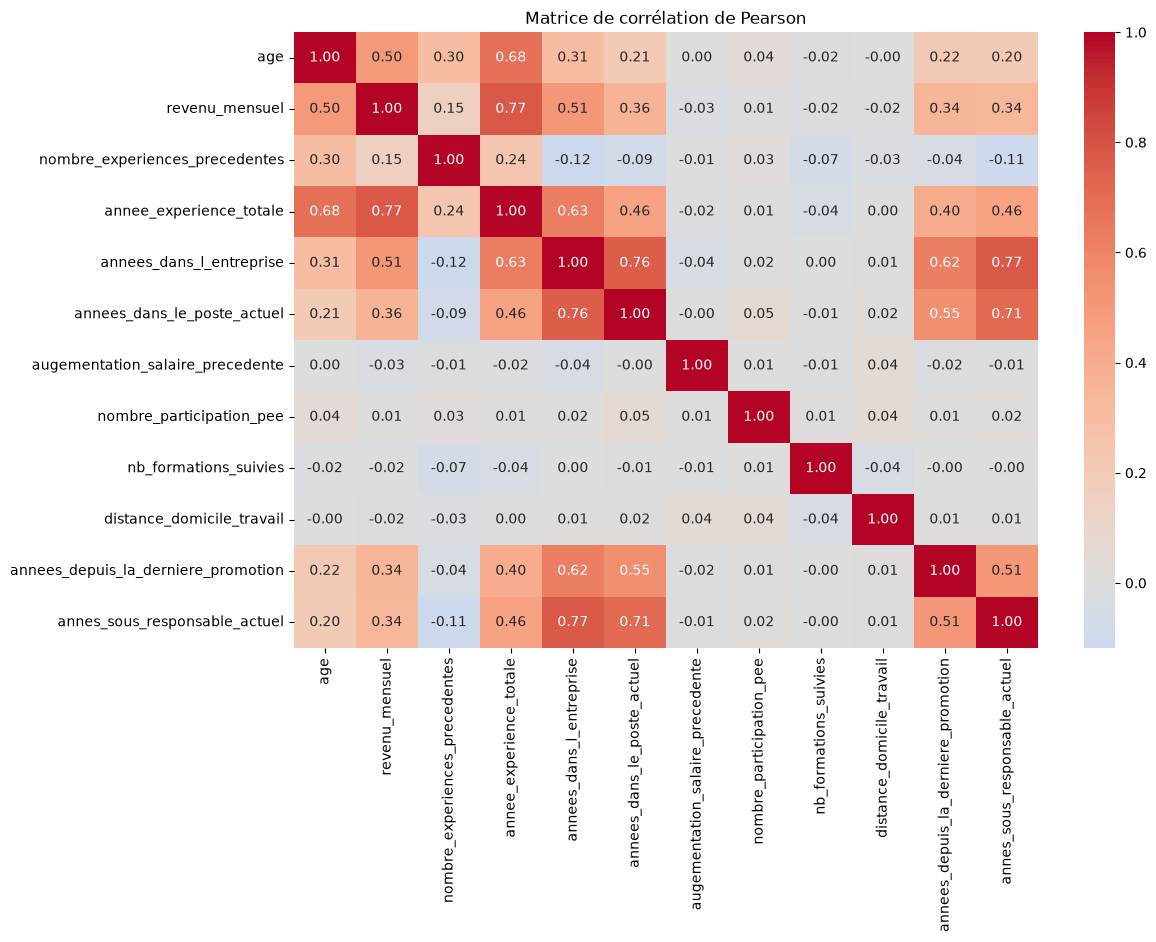

In [36]:
# Visualisation de la matrice de corrélation

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation de Pearson")
plt.show()

> - **Matrice de corrélation de Pearson** : L'analyse met en évidence plusieurs corrélations linéaires fortes entre certaines variables quantitatives :
>   - `revenu_mensuel` et `annee_experience_totale` : **r = 0,77** ;
>   - `annees_dans_l_entreprise` et `annees_dans_le_poste_actuel` : **r = 0,76** ;
>   - `annees_dans_l_entreprise` et `annees_sous_responsable_actuel` : **r = 0,77** ;
>   - `annees_dans_le_poste_actuel` et `annees_sous_responsable_actuel` : **r = 0,71**.
>
> - Ces corrélations indiquent une possible redondance entre certaines variables.
>
> - Aucune variable n'est supprimée à ce stade. Leur pertinence sera réévaluée en fonction de leur **sens métier** et des résultats de la modélisation.

### **Pairplot - Corrélations non-linéaires**

#### **Revenu et expérience totale**

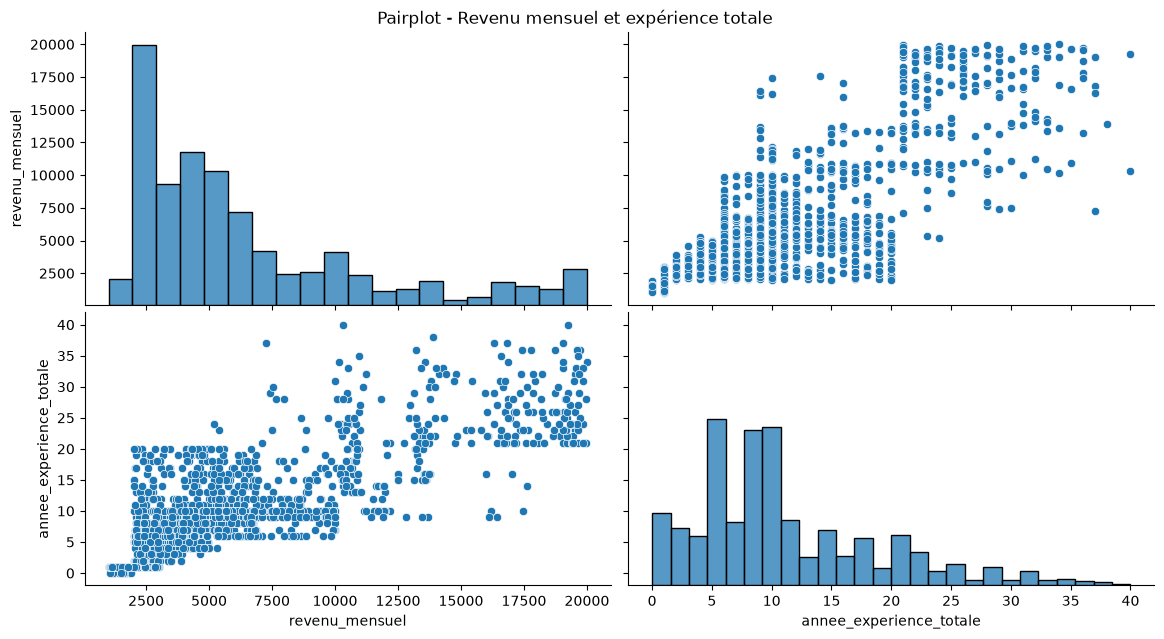

In [44]:
# Pairplot - Revenu et expérience totale

g = sns.pairplot(
    X_quant[
        [
            "revenu_mensuel",
            "annee_experience_totale"
        ]
    ],
    height=5
)

g.fig.set_size_inches(12, 6)

g.fig.suptitle(
    "Pairplot - Revenu mensuel et expérience totale",
    y=1.02
)

plt.show()

> - Le pairplot montre une relation positive entre les deux variables : le revenu mensuel tend à augmenter avec l'expérience totale.
>
> - Cette observation est cohérente avec la **corrélation de Pearson (r = 0,77)**, qui indique une forte corrélation linéaire entre les deux variables.

#### **Ancienneté entreprise × poste actuel**

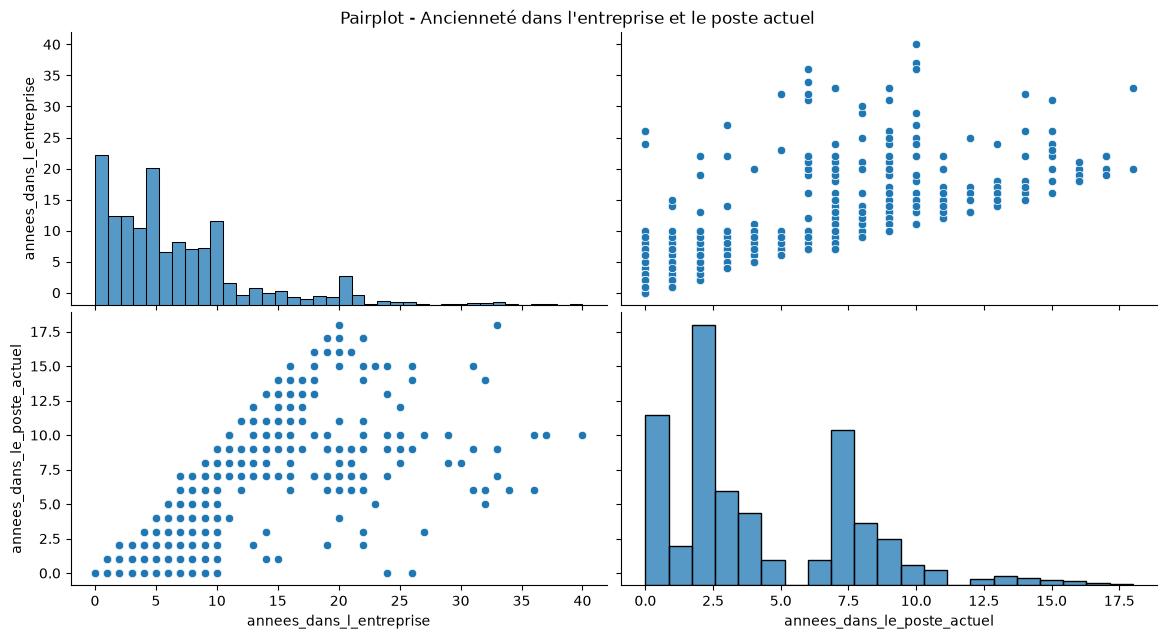

In [57]:
# Pairplot - Ancienneté dans l'entreprise et le poste

g = sns.pairplot(
    X_quant[
        [
            "annees_dans_l_entreprise",
            "annees_dans_le_poste_actuel"
        ]
    ],
    height=5
)

g.fig.set_size_inches(12, 6)

g.fig.suptitle(
    "Pairplot - Ancienneté dans l'entreprise et le poste actuel",
    y=1.02
)

plt.show()

> - Le pairplot montre une relation positive entre l'ancienneté dans l'entreprise et l'ancienneté dans le poste actuel.
>
> - Cette observation est cohérente avec la **corrélation de Pearson (r = 0,76)**, qui indique une forte corrélation linéaire entre les deux variables.

#### **Ancienneté entreprise × responsable actuel**

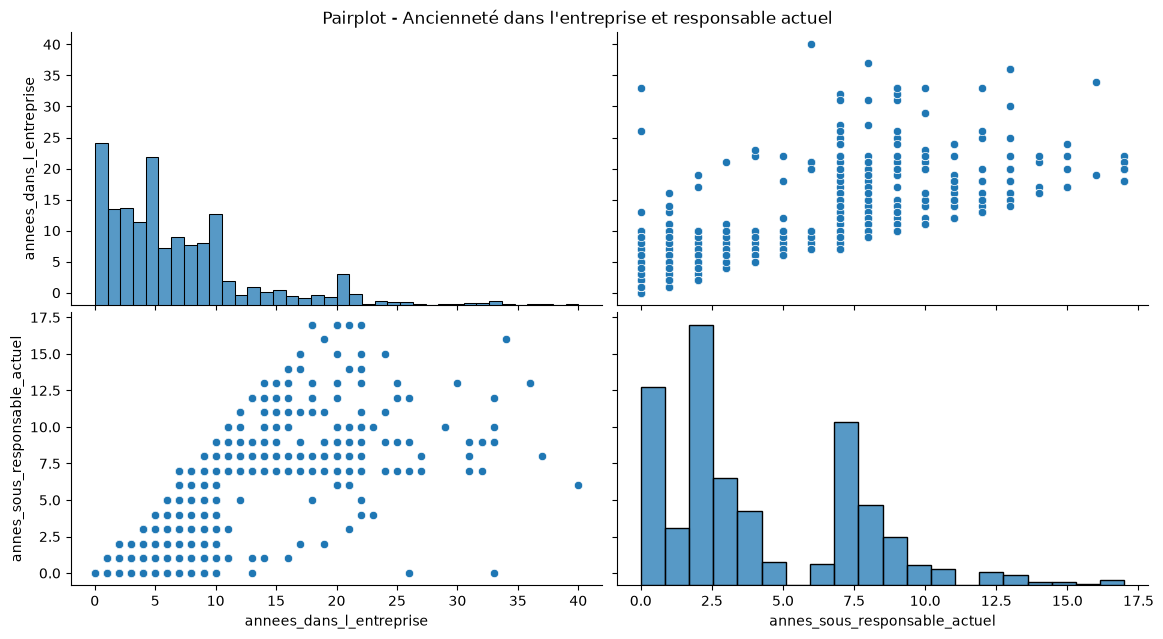

In [58]:
# Pairplot - Ancienneté dans l'entreprise et responsable actuel

g = sns.pairplot(
    X_quant[
        [
            "annees_dans_l_entreprise",
            "annes_sous_responsable_actuel"
        ]
    ],
    height=5
)

g.fig.set_size_inches(12, 6)

g.fig.suptitle(
    "Pairplot - Ancienneté dans l'entreprise et responsable actuel",
    y=1.02
)

plt.show()

> - Le pairplot met en évidence une relation positive et globalement monotone entre les deux variables.
>
> - Les employés ayant davantage d'ancienneté dans l'entreprise tendent également à avoir davantage d'années sous la responsabilité de leur responsable actuel.
>
> - Cette observation est cohérente avec la **corrélation de Pearson (r = 0,77)**, qui indique une forte corrélation linéaire entre les deux variables.

#### **Poste actuel × responsable actuel**

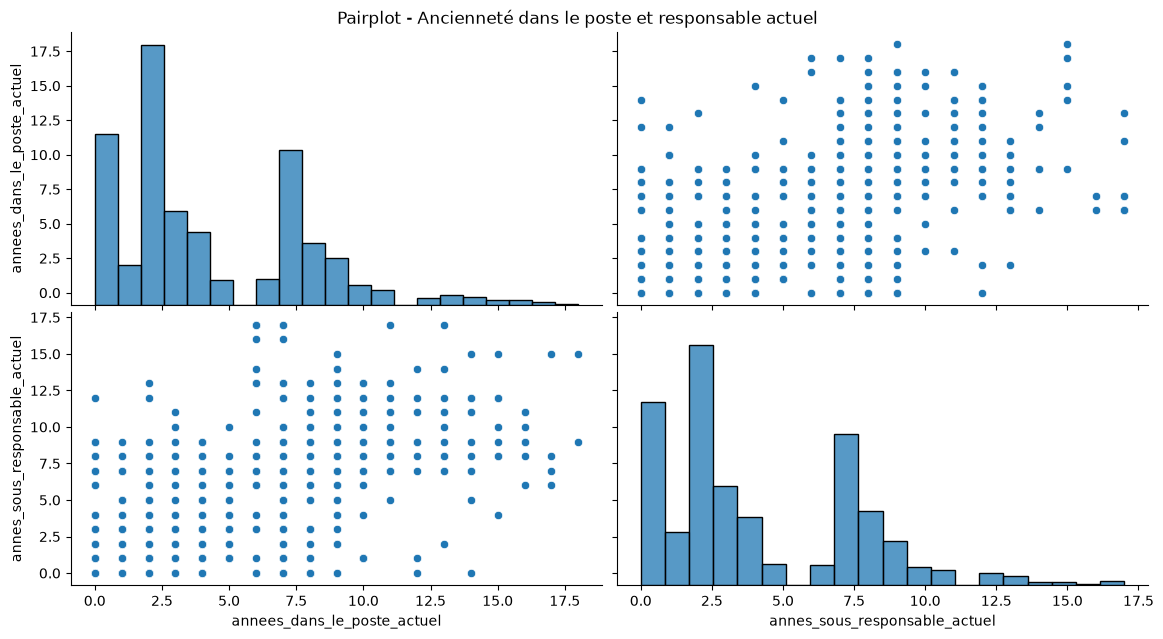

In [61]:
# Pairplot - Ancienneté dans le poste et responsable actuel

g = sns.pairplot(
    X_quant[
        [
            "annees_dans_le_poste_actuel",
            "annes_sous_responsable_actuel"
        ]
    ],
    height=5
)

g.fig.set_size_inches(12, 6)

g.fig.suptitle(
    "Pairplot - Ancienneté dans le poste et responsable actuel",
    y=1.02
)

plt.show()

> - Le pairplot montre une relation positive entre les deux variables, mais avec une dispersion plus importante que pour les relations précédentes
> - Cette observation est cohérente avec la **corrélation de Pearson (r = 0,71)**, qui indique une forte corrélation linéaire entre les deux variables.

#### **Age × annee_experience_totale**

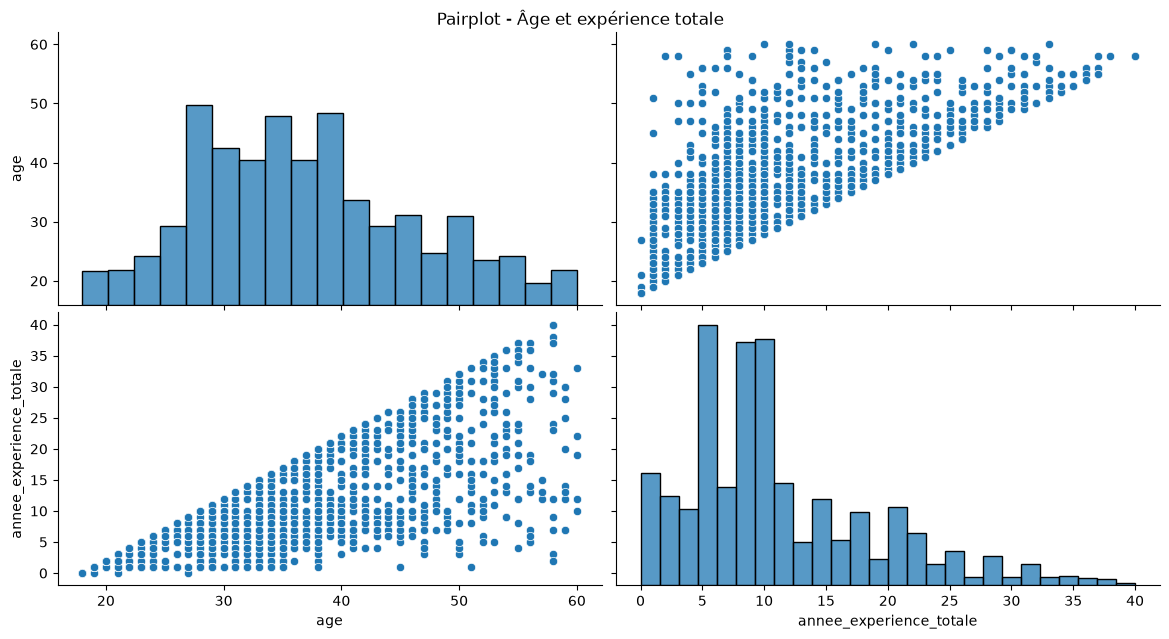

In [62]:
# Pairplot - Âge et expérience totale

g = sns.pairplot(
    X_quant[
        [
            "age",
            "annee_experience_totale"
        ]
    ],
    height=5
)

g.fig.set_size_inches(12, 6)

g.fig.suptitle(
    "Pairplot - Âge et expérience totale",
    y=1.02
)

plt.show()

> - **`Age` et `Annee_experience_totale`** : Le pairplot montre une relation positive et globalement croissante entre l'âge et l'expérience totale.
> - La dispersion augmente avec l'âge, notamment pour les employés les plus âgés, qui indique une corrélation linéaire modérée à forte entre les deux variables.

#### **Annee_experience_totale × Annees_dans_l_entreprise**

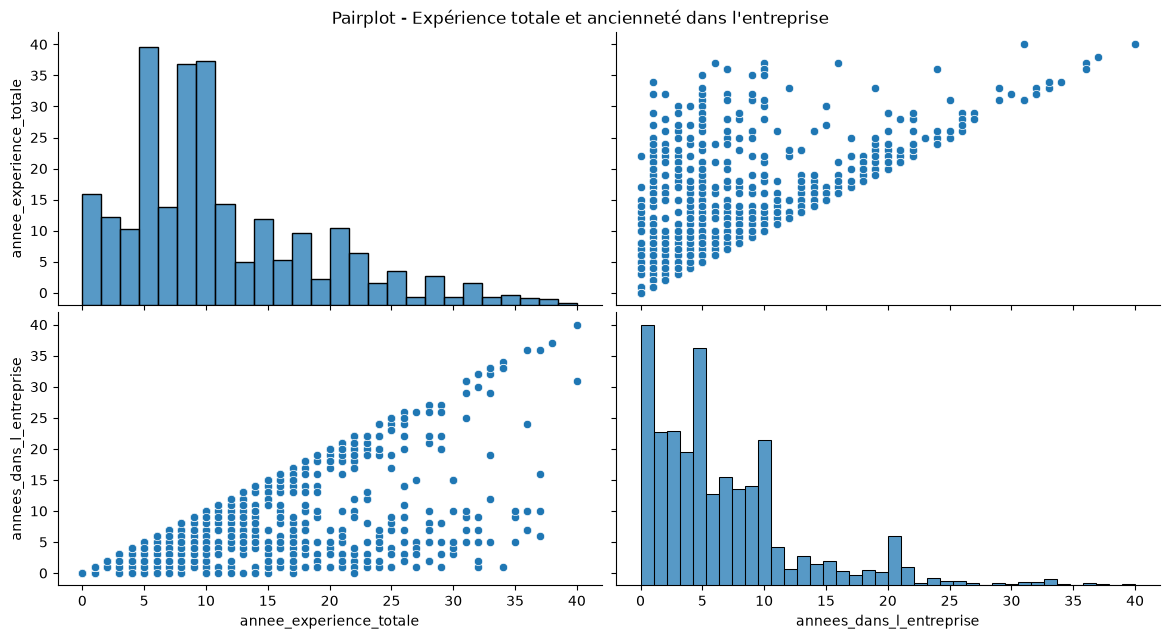

In [63]:
# Pairplot - Expérience totale et ancienneté dans l'entreprise

g = sns.pairplot(
    X_quant[
        [
            "annee_experience_totale",
            "annees_dans_l_entreprise"
        ]
    ],
    height=5
)

g.fig.set_size_inches(12, 6)

g.fig.suptitle(
    "Pairplot - Expérience totale et ancienneté dans l'entreprise",
    y=1.02
)

plt.show()

> - Une relation positive et globalement croissante entre l'expérience totale et l'ancienneté dans l'entreprise.
> - La relation présente une certaine dispersion, notamment pour les employés ayant une expérience totale élevée, qui indique une corrélation linéaire modérée à forte entre les deux variables.

#### **Annees_dans_l_entreprise × Annees_depuis_la_derniere_promotion**

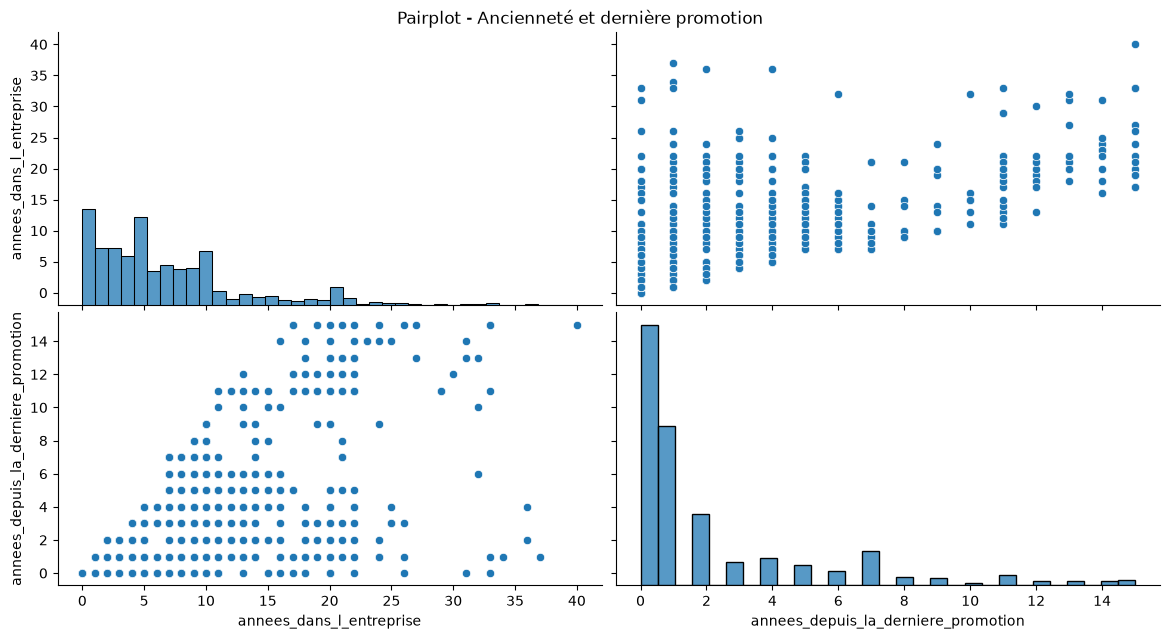

In [64]:
# Pairplot - Ancienneté et dernière promotion

g = sns.pairplot(
    X_quant[
        [
            "annees_dans_l_entreprise",
            "annees_depuis_la_derniere_promotion"
        ]
    ],
    height=5
)

g.fig.set_size_inches(12, 6)

g.fig.suptitle(
    "Pairplot - Ancienneté et dernière promotion",
    y=1.02
)

plt.show()

> - Le pairplot montre une relation positive entre l'ancienneté dans l'entreprise et le nombre d'années depuis la dernière promotion.
> - La relation est globalement croissante, mais présente une dispersion importante et plusieurs valeurs atypiques, qui indique une corrélation linéaire modérée à forte entre les deux variables.

### **Matrice de corrélation de Spearman**

In [65]:
# Matrice de corrélation de Spearman

correlation_spearman = X_quant.corr(method="spearman")

display(correlation_spearman)

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,augementation_salaire_precedente,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
age,1.000000,0.471902,0.353213,0.656896,0.251686,0.197978,0.007709,0.056633,0.000316,-0.019291,0.173647,0.194818
revenu_mensuel,0.471902,1.000000,0.190307,0.710024,0.464315,0.394712,-0.033767,0.045852,-0.034847,0.002512,0.264599,0.365386
nombre_experiences_precedentes,0.353213,0.190307,1.000000,0.315196,-0.171070,-0.127673,0.000046,0.032277,-0.047336,-0.009592,-0.066950,-0.144129
annee_experience_totale,0.656896,0.710024,0.315196,1.000000,0.594193,0.492721,-0.025528,0.052618,-0.014151,-0.002912,0.334996,0.495254
annees_dans_l_entreprise,0.251686,0.464315,-0.171070,0.594193,1.000000,0.854000,-0.054117,0.064974,0.001389,0.010513,0.519966,0.842803
annees_dans_le_poste_actuel,0.197978,0.394712,-0.127673,0.492721,0.854000,1.000000,-0.025528,0.071627,0.004581,0.013708,0.505657,0.724754
augementation_salaire_precedente,0.007709,-0.033767,0.000046,-0.025528,-0.054117,-0.025528,1.000000,0.023446,-0.004106,0.029666,-0.055362,-0.026049
nombre_participation_pee,0.056633,0.045852,0.032277,0.052618,0.064974,0.071627,0.023446,1.000000,0.003388,0.030190,0.027502,0.053646
nb_formations_suivies,0.000316,-0.034847,-0.047336,-0.014151,0.001389,0.004581,-0.004106,0.003388,1.000000,-0.024848,0.010215,-0.011628
distance_domicile_travail,-0.019291,0.002512,-0.009592,-0.002912,0.010513,0.013708,0.029666,0.030190,-0.024848,1.000000,-0.004685,0.004448


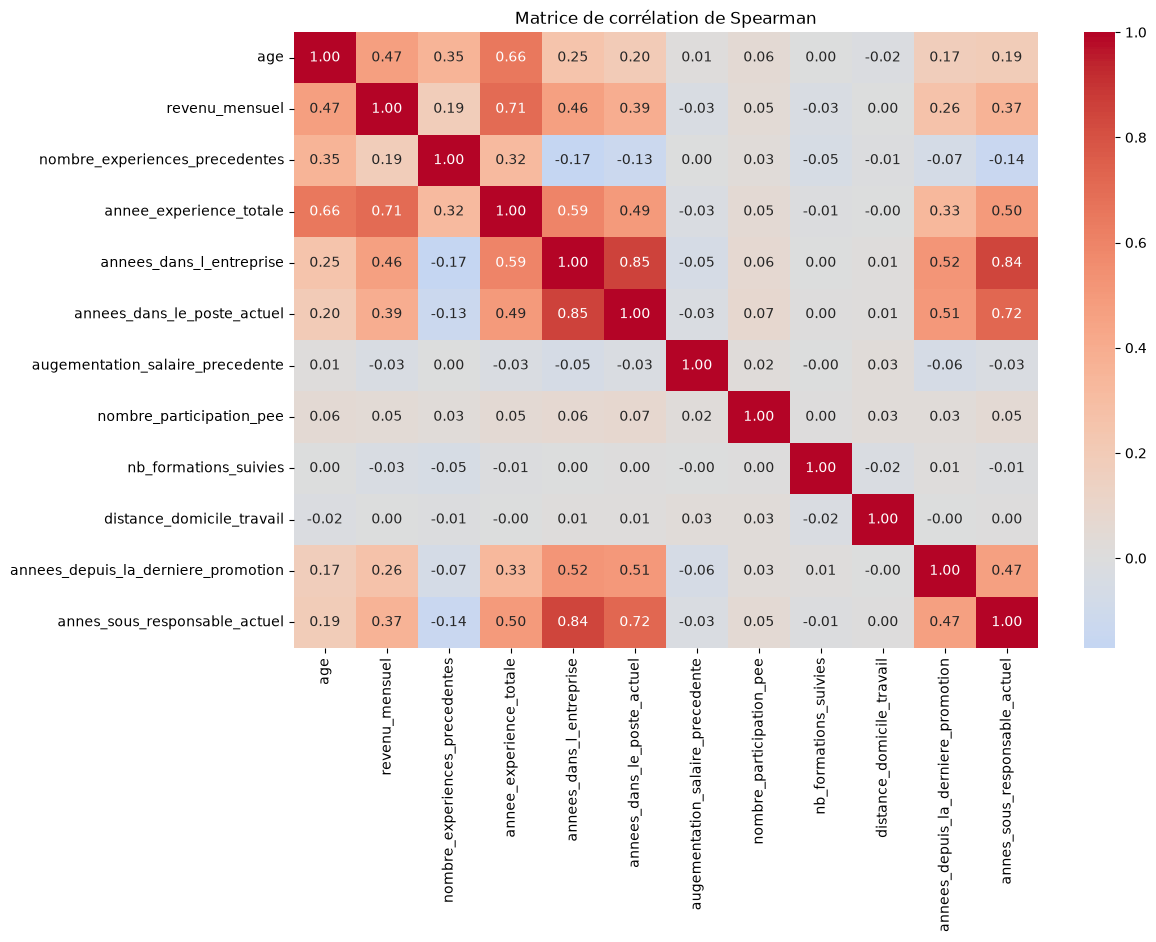

In [66]:
# Visualisation de la matrice de corrélation de Spearman

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation de Spearman")
plt.show()

> - L'analyse confirme plusieurs relations monotoniques fortes entre les variables quantitatives.
>   - Les corrélations les plus importantes concernent `annees_dans_l_entreprise` avec `annees_dans_le_poste_actuel` (**r = 0,85**) et avec `annees_sous_responsable_actuel` (**r = 0,84**).
>   - La relation entre `revenu_mensuel` et `annee_experience_totale` reste également forte (**r = 0,71**), confirmant une association monotone entre l'expérience et le revenu.
>   - Les résultats de Spearman confirment donc les principales relations identifiées avec Pearson et mettent en évidence une forte dépendance entre certaines variables liées à l'ancienneté.

### **Sélection des variables fortement corrélées**

> - L'analyse des matrices de Pearson et de Spearman met en évidence de fortes corrélations entre les variables liées à l'ancienneté.
>
>   - `annees_dans_l_entreprise` présente notamment une forte corrélation avec `annees_dans_le_poste_actuel` (**r = 0,85**) et `annees_sous_responsable_actuel` (**r = 0,84**) selon la corrélation de Spearman.
>   -  Afin de limiter la redondance entre les features, **`annees_dans_l_entreprise` est conservée** comme indicateur global d'ancienneté.
>   - Les variables `annees_dans_le_poste_actuel` et `annees_sous_responsable_actuel` sont donc exclues des features utilisées pour la modélisation.

In [68]:
# Suppression des variables fortement corrélées

X = X.drop(
    columns=[
        "annees_dans_le_poste_actuel",
        "annes_sous_responsable_actuel"
    ]
)

print("Nouvelles dimensions de X :", X.shape)

Nouvelles dimensions de X : (1470, 25)


### **Méthode d’encodage**

#### **Liste des variables Qualitatives**

Bien comprendre quand utiliser un OneHotEncoder ou une autre méthode d'encodage pour les features qualitatives.

> - **Variables qualitatives nominales** : elles représentent des catégories sans ordre naturel et seront encodées à l'aide du **OneHotEncoder**.
>
> - **Variables qualitatives ordinales** : elles présentent un ordre naturel entre leurs valeurs. Certaines sont actuellement enregistrées en `int64`, mais sont considérées comme qualitatives selon leur sens métier.
>
>   - Leur représentation numérique sera vérifiée afin de confirmer qu'elle respecte bien leur **ordre métier** avant de déterminer leur traitement final.

In [71]:
# Vérification des variables qualitatives

variables_qualitatives = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "heure_supplementaires",
    "niveau_education",
    "domaine_etude",
    "frequence_deplacement"
]

for variable in variables_qualitatives:
    print(f"\n{variable}")
    print(X[variable].unique())


genre
<StringArray>
['F', 'M']
Length: 2, dtype: str

statut_marital
<StringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str

departement
<StringArray>
['Commercial', 'Consulting', 'Ressources Humaines']
Length: 3, dtype: str

poste
<StringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str

satisfaction_employee_environnement
[2 3 4 1]

note_evaluation_precedente
[3 2 4 1]

niveau_hierarchique_poste
[2 1 3 4 5]

satisfaction_employee_nature_travail
[4 2 3 1]

satisfaction_employee_equipe
[1 4 2 3]

satisfaction_employee_equilibre_pro_perso
[1 3 2 4]

note_evaluation_actuelle
[3 4]

heure_supplementaires
<StringArray>
['Oui', 'Non']
Length: 2, dtype: str

niveau_education
[2 1 4 3 5]

domaine_etude
<StringArray>
[          'Infra & Cloud',   

In [74]:
# Classification des variables qualitatives

classification_qualitatives = pd.DataFrame({
    "Variable": [
        "genre",
        "statut_marital",
        "departement",
        "poste",
        "heure_supplementaires",
        "domaine_etude",
        "frequence_deplacement",
        "satisfaction_employee_environnement",
        "note_evaluation_precedente",
        "niveau_hierarchique_poste",
        "satisfaction_employee_nature_travail",
        "satisfaction_employee_equipe",
        "satisfaction_employee_equilibre_pro_perso",
        "note_evaluation_actuelle",
        "niveau_education"
    ],
    
    "Modalités observées": [
        "F, M",
        "Célibataire, Marié(e), Divorcé(e)",
        "Commercial, Consulting, Ressources Humaines",
        "Cadre Commercial, Assistant de Direction, Consultant, Tech Lead, Manager, Senior Manager, Représentant Commercial, Directeur Technique, Ressources Humaines",
        "Oui, Non",
        "Infra & Cloud, Autre, Transformation Digitale, Marketing, Entrepreunariat, Ressources Humaines",
        "Aucun, Occasionnel, Frequent",
        "1, 2, 3, 4",
        "1, 2, 3, 4",
        "1, 2, 3, 4, 5",
        "1, 2, 3, 4",
        "1, 2, 3, 4",
        "1, 2, 3, 4",
        "3, 4",
        "1, 2, 3, 4, 5"
    ],
    
    "Type": [
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale",
        "Ordinale",
        "Ordinale",
        "Ordinale",
        "Ordinale",
        "Ordinale",
        "Ordinale",
        "Ordinale",
        "Ordinale"
    ],
    
    "Décision d'Encodage": [
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "Conservation numérique",
        "Conservation numérique",
        "Conservation numérique",
        "Conservation numérique",
        "Conservation numérique",
        "Conservation numérique",
        "Conservation numérique",
        "Conservation numérique"
    ]
})

display(classification_qualitatives)

,Variable,Modalités observées,Type,Décision d'Encodage
0,genre,"F, M",Nominale,OneHotEncoder
1,statut_marital,"Célibataire, Marié(e), Divorcé(e)",Nominale,OneHotEncoder
2,departement,"Commercial, Consulting, Ressources Humaines",Nominale,OneHotEncoder
3,poste,"Cadre Commercial, Assistant de Direction, Cons...",Nominale,OneHotEncoder
4,heure_supplementaires,"Oui, Non",Nominale,OneHotEncoder
5,domaine_etude,"Infra & Cloud, Autre, Transformation Digitale,...",Nominale,OneHotEncoder
6,frequence_deplacement,"Aucun, Occasionnel, Frequent",Nominale,OneHotEncoder
7,satisfaction_employee_environnement,"1, 2, 3, 4",Ordinale,Conservation numérique
8,note_evaluation_precedente,"1, 2, 3, 4",Ordinale,Conservation numérique
9,niveau_hierarchique_poste,"1, 2, 3, 4, 5",Ordinale,Conservation numérique


> - Les variables qualitatives ont été distinguées selon leur **nature métier**.
>
>   - Les 7 variables **nominales** (`genre`, `statut_marital`, `departement`, `poste`, `heure_supplementaires`, `domaine_etude`, `frequence_deplacement`) seront encodées avec un **OneHotEncoder**, car leurs modalités ne présentent pas d'ordre naturel.
>
>   - Les 8 variables **ordinales** conserveront leur représentation numérique, car leurs valeurs respectent un ordre métier.
>
>⚠️ note_evaluation_actuelle est une variable ordinale dont les modalités observées dans notre jeu de données sont uniquement **3 et 4**.

#### **OneHotEncoder**

##### **Variables qualitatives nominales**

In [91]:
# Classification des variables qualitatives nominales = OneHotEncoder

classification_qualitatives_nominales = pd.DataFrame({
    "Variable": [
        "genre",
        "statut_marital",
        "departement",
        "poste",
        "heure_supplementaires",
        "domaine_etude",
        "frequence_deplacement",
    ],
    
    "Modalités observées": [
        "F, M",
        "Célibataire, Marié(e), Divorcé(e)",
        "Commercial, Consulting, Ressources Humaines",
        "Cadre Commercial, Assistant de Direction, Consultant, Tech Lead, Manager, Senior Manager, Représentant Commercial, Directeur Technique, Ressources Humaines",
        "Oui, Non",
        "Infra & Cloud, Autre, Transformation Digitale, Marketing, Entrepreunariat, Ressources Humaines",
        "Aucun, Occasionnel, Frequent"
    ],
    
    "Type": [
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale",
        "Nominale"
    ],
    
    "Décision d'Encodage": [
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder"
    ]
})

display(classification_qualitatives_nominales)

,Variable,Modalités observées,Type,Décision d'Encodage
0,genre,"F, M",Nominale,OneHotEncoder
1,statut_marital,"Célibataire, Marié(e), Divorcé(e)",Nominale,OneHotEncoder
2,departement,"Commercial, Consulting, Ressources Humaines",Nominale,OneHotEncoder
3,poste,"Cadre Commercial, Assistant de Direction, Cons...",Nominale,OneHotEncoder
4,heure_supplementaires,"Oui, Non",Nominale,OneHotEncoder
5,domaine_etude,"Infra & Cloud, Autre, Transformation Digitale,...",Nominale,OneHotEncoder
6,frequence_deplacement,"Aucun, Occasionnel, Frequent",Nominale,OneHotEncoder


In [88]:
# Variables qualitatives nominales (Niveau_education et note_evaluation_actuelle sont supprimées car elles sont ordinales, les autres sont nominales)

variables_nominales = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "heure_supplementaires",
    "domaine_etude",
    "frequence_deplacement"
]

print ("Variables qualitatives nominales :", variables_nominales)

print("Dimensions de X :", X.shape)

Variables qualitatives nominales : ['genre', 'statut_marital', 'departement', 'poste', 'heure_supplementaires', 'domaine_etude', 'frequence_deplacement']
Dimensions de X : (1470, 25)


>   - 10 quantitatives + 8 ordinales + 7 nominales = 25 features

##### **Variables qualitatives ordinales**

In [77]:
# Variables qualitatives ordinales

variables_ordinales = [
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "niveau_education"
]

print("Variables qualitatives ordinales :", variables_ordinales)

Variables qualitatives ordinales : ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'niveau_education']


In [78]:
# Vérification des variables qualitatives

print("Variables nominales :", len(variables_nominales))
print("Variables ordinales :", len(variables_ordinales))
print("Total :", len(variables_nominales) + len(variables_ordinales))

Variables nominales : 7
Variables ordinales : 8
Total : 15


##### **Variables quantitatives**

In [81]:
variables_numeriques = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "augmentation_salaire_precedente",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "annees_depuis_la_derniere_promotion"
]

print("Variables numériques :", len(variables_numeriques))

Variables numériques : 10


##### **Création du ColumnTransformer**

In [96]:
# Préparation du préprocesseur pour les variables qualitatives nominales

preprocessor = ColumnTransformer(
    transformers=[
        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            variables_nominales
        )
    ],
    remainder="passthrough"
)

In [97]:
# Vérification des dimensions après preprocessing

X_transformed = preprocessor.fit_transform(X)

print("Shape de X avant encodage :", X.shape)
print("Shape de X après encodage :", X_transformed.shape)

Shape de X avant encodage : (1470, 25)
Shape de X après encodage : (1470, 46)


> - **OneHotEncoder** : Les variables qualitatives nominales sont transformées en variables binaires, avec une colonne créée pour chaque modalité observée.
> - Par exemple, la variable `genre` avec les modalités `F` et `M` devient deux variables : `genre_F` et `genre_M`.
> - Les **7 variables nominales** sont ainsi transformées en **28 variables**, tandis que les **18 autres variables** (quantitatives et ordinales) sont conservées sans transformation.
> - Ainsi, `X` passe de **25 features à 46 features** après l'encodage.

### **Vérification du preprocessing**

In [85]:
# Vérification du résultat du preprocessing

print("Type de X_transformed :", type(X_transformed))
print("Présence de valeurs manquantes :", np.isnan(X_transformed).any())
print("Type des données :", X_transformed.dtype)

Type de X_transformed : <class 'numpy.ndarray'>
Présence de valeurs manquantes : False
Type des données : float64


> - Le preprocessing a été réalisé sans erreur et le résultat est un tableau `numpy.ndarray`.
> - Aucune valeur manquante n'a été détectée dans les features transformées.
> - Toutes les variables sont désormais numériques (`float64`), ce qui permet leur utilisation avec les méthodes de modélisation de `scikit-learn`.

### **Création du DataFrame final**

In [98]:
# Récupération des noms des features après encodage

feature_names = preprocessor.get_feature_names_out()

X = pd.DataFrame(
    X_transformed,
    columns=feature_names,
    index=X.index
)

print("Shape de X final :", X.shape)

Shape de X final : (1470, 46)


In [99]:
# Récupération des noms des features après encodage

feature_names = preprocessor.get_feature_names_out()

X = pd.DataFrame(
    X_transformed,
    columns=feature_names,
    index=X.index
)

print("Shape de X final :", X.shape)

Shape de X final : (1470, 46)


In [100]:
# Vérification du DataFrame final

display(X.head())

print("\nType de X :", type(X))
print("Valeurs manquantes :", X.isna().sum().sum())
print("Nombre de features :", X.shape[1])

,nominal__genre_F,nominal__genre_M,nominal__statut_marital_Célibataire,nominal__statut_marital_Divorcé(e),nominal__statut_marital_Marié(e),nominal__departement_Commercial,nominal__departement_Consulting,nominal__departement_Ressources Humaines,nominal__poste_Assistant de Direction,nominal__poste_Cadre Commercial,...,remainder__satisfaction_employee_nature_travail,remainder__satisfaction_employee_equipe,remainder__satisfaction_employee_equilibre_pro_perso,remainder__note_evaluation_actuelle,remainder__augementation_salaire_precedente,remainder__nombre_participation_pee,remainder__nb_formations_suivies,remainder__distance_domicile_travail,remainder__niveau_education,remainder__annees_depuis_la_derniere_promotion
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,4.0,1.0,1.0,3.0,11.0,0.0,0.0,1.0,2.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,2.0,4.0,3.0,4.0,23.0,1.0,3.0,8.0,1.0,1.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,2.0,3.0,3.0,15.0,0.0,3.0,2.0,2.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,3.0,3.0,3.0,3.0,11.0,0.0,3.0,3.0,4.0,3.0
4,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,2.0,4.0,3.0,3.0,12.0,1.0,3.0,2.0,1.0,2.0



Type de X : <class 'pandas.DataFrame'>
Valeurs manquantes : 0
Nombre de features : 46


> - Après le prétraitement, le jeu de données contient **1 470 observations et 46 features**.
> - Les variables qualitatives nominales ont été encodées avec un `OneHotEncoder` et le DataFrame final `X` ne contient **aucune valeur manquante** et l'ensemble des features est numérique.
> - `X` est ainsi prêt à être utilisé comme matrice de features dans les méthodes de modélisation de `scikit-learn`.

### **Création d'une fonction de préparation des données**

In [105]:
def prepare_data(df):
    """
    Prépare les données pour la modélisation.

    Retourne :
    - X : DataFrame contenant les features prêtes pour le ML
    - y : Series contenant la variable cible
    """

    # Variable cible
    y = df["a_quitte_l_entreprise"].copy()

    # Features
    X = df.drop(columns=["a_quitte_l_entreprise", "id_employee"]).copy()

    # Suppression des variables fortement corrélées
    X = X.drop(
        columns=[
            "annees_dans_le_poste_actuel",
            "annes_sous_responsable_actuel"
        ]
    )

    # Preprocessing et encodage
    X_transformed = preprocessor.fit_transform(X)

    # Récupération des noms des features
    feature_names = preprocessor.get_feature_names_out()

    # DataFrame final
    X = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )

    return X, y

print("Préparation des données terminée.")

Préparation des données terminée.


In [106]:
# Préparation finale des données

X, y = prepare_data(df_central)

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (1470, 46)
Shape de y : (1470,)


### **Conclusion de la préparation pour la modelisation**

In [107]:
# Validation finale de X et y

print("Type de X :", type(X))
print("Type de y :", type(y))

print("\nShape de X :", X.shape)
print("Shape de y :", y.shape)

print("\nValeurs manquantes dans X :", X.isna().sum().sum())
print("Valeurs manquantes dans y :", y.isna().sum())

print("\nToutes les features de X sont numériques :",
      X.dtypes.apply(lambda dtype: np.issubdtype(dtype, np.number)).all())

print("\nMême nombre d'observations :", len(X) == len(y))

Type de X : <class 'pandas.DataFrame'>
Type de y : <class 'pandas.Series'>

Shape de X : (1470, 46)
Shape de y : (1470,)

Valeurs manquantes dans X : 0
Valeurs manquantes dans y : 0

Toutes les features de X sont numériques : True

Même nombre d'observations : True


> - Le DataFrame `X` contient les features prêtes pour la modélisation.
> - La variable cible `y` est conservée séparément sous forme de `Series`.
> - Une dernière vérification permet de confirmer les types, les dimensions, l'absence de valeurs manquantes et la compatibilité entre `X` et `y`.

### **Sauvegarde du dataset**

In [113]:
# Création du dossier de sortie

import os

os.makedirs("../data/processed", exist_ok=True)

# Création du DataFrame final de modélisation

df_modelisation = X.copy()
df_modelisation["a_quitte_l_entreprise"] = y.values

# Exportation

df_modelisation.to_csv(
    "../data/processed/df_modelisation.csv",
    index=False
)

print("Exportation terminée.")
print("Dimensions :", df_modelisation.shape)

Exportation terminée.
Dimensions : (1470, 47)


In [109]:
# Vérification des fichiers exportés

X_check = pd.read_csv("../data/processed/X.csv")
y_check = pd.read_csv("../data/processed/y.csv")

print("X :", X_check.shape)
print("y :", y_check.shape)

X : (1470, 46)
y : (1470, 1)


In [114]:
# Vérification du fichier exporté

df_check = pd.read_csv("../data/processed/df_modelisation.csv")

print("Dimensions :", df_check.shape)
print("Valeurs manquantes :", df_check.isna().sum().sum())
print("Nombre de features :", df_check.shape[1] - 1)

Dimensions : (1470, 47)
Valeurs manquantes : 0
Nombre de features : 46
